In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ImageNet

## Només estratègies DLFuzz

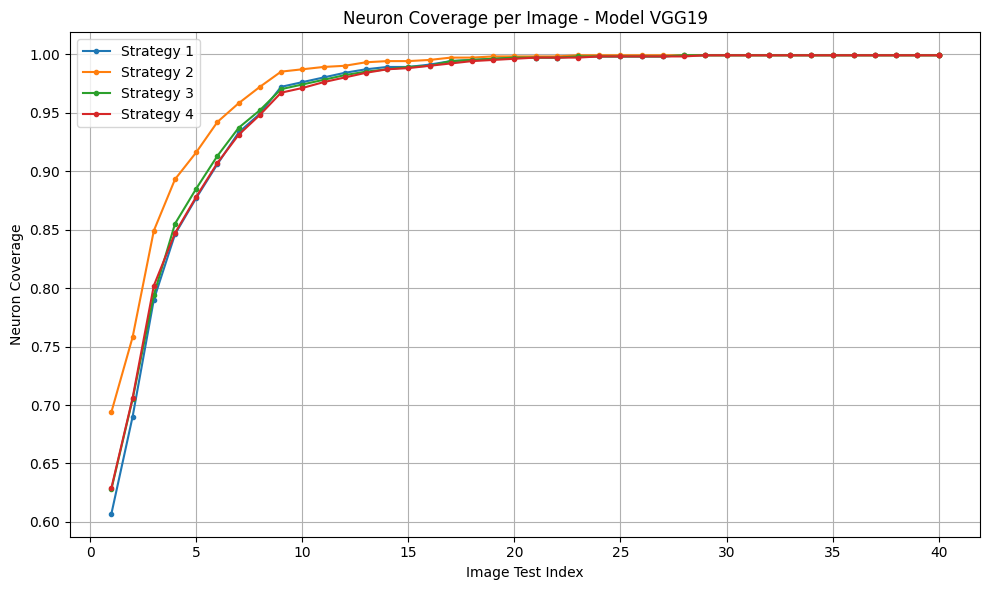

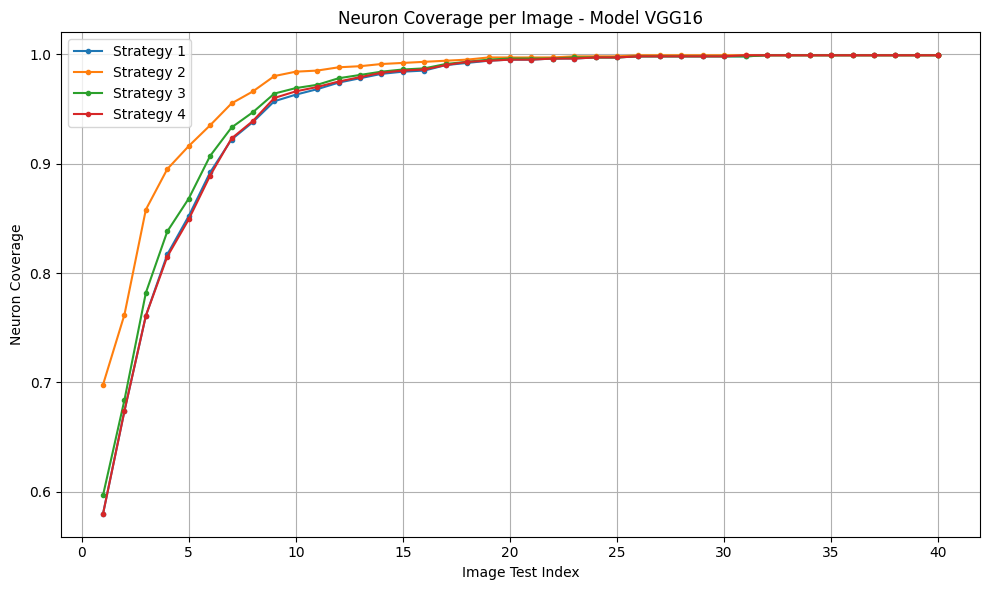

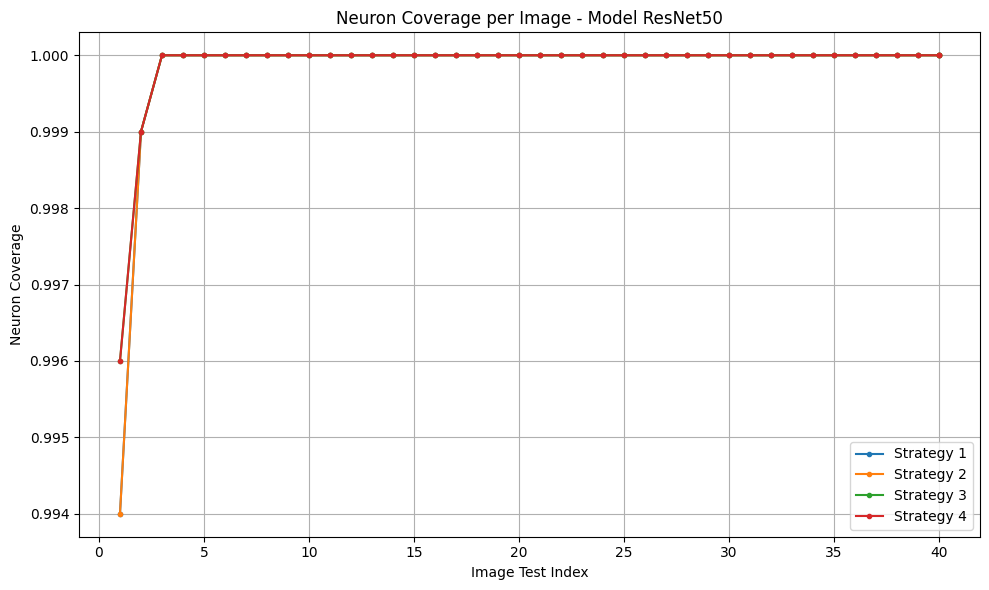

In [ ]:
import os
import re
import matplotlib.pyplot as plt

folder_path = "TFG/DLFuzz/Resultats_imagenet"

# Diccionari: model -> {estratègia -> (x_vals, y_vals)}
models_data = {}

for filename in os.listdir(folder_path):
    if filename.endswith(".txt") and "DLFuzz_imagenet_10" in filename:
        filepath = os.path.join(folder_path, filename)

        match = re.search(r'DLFuzz_imagenet_10_(\d+)(\d+)\.txt', filename)
        if match:
            model = int(match.group(1))
            strategy = int(match.group(2))+1

            with open(filepath, "r") as f:
                lines = f.readlines()

            image_index = 0
            x_vals = []
            y_vals = []

            for line in lines:
                if line.startswith("Image path:"):
                    image_index += 1
                elif "covered neurons percentage" in line:
                    match_cov = re.search(r'([0-9.]+)\s*$', line)
                    if match_cov:
                        coverage = float(match_cov.group(1))
                        x_vals.append(image_index)
                        y_vals.append(coverage)

            if model not in models_data:
                models_data[model] = {}
            models_data[model][strategy] = (x_vals, y_vals)

for model, strategies in models_data.items():
    plt.figure(figsize=(10, 6))
    # for strategy, (x, y) in strategies.items():
    #     label = f"Strategy {strategy}"
    #     plt.plot(x, y, label=label)#, marker='o')
    for strategy in sorted(strategies.keys()):
        x, y = strategies[strategy]
        label = f"Strategy {strategy}"
        plt.plot(x, y, label=label, marker='o', markersize=3)
    if model == 1:
        plt.title(f"Neuron Coverage per Image - Model VGG16")
    elif model == 2:
        plt.title(f"Neuron Coverage per Image - Model VGG19")
    elif model == 3:
        plt.title(f"Neuron Coverage per Image - Model ResNet50")
    plt.xlabel("Image Test Index")
    plt.ylabel("Neuron Coverage")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


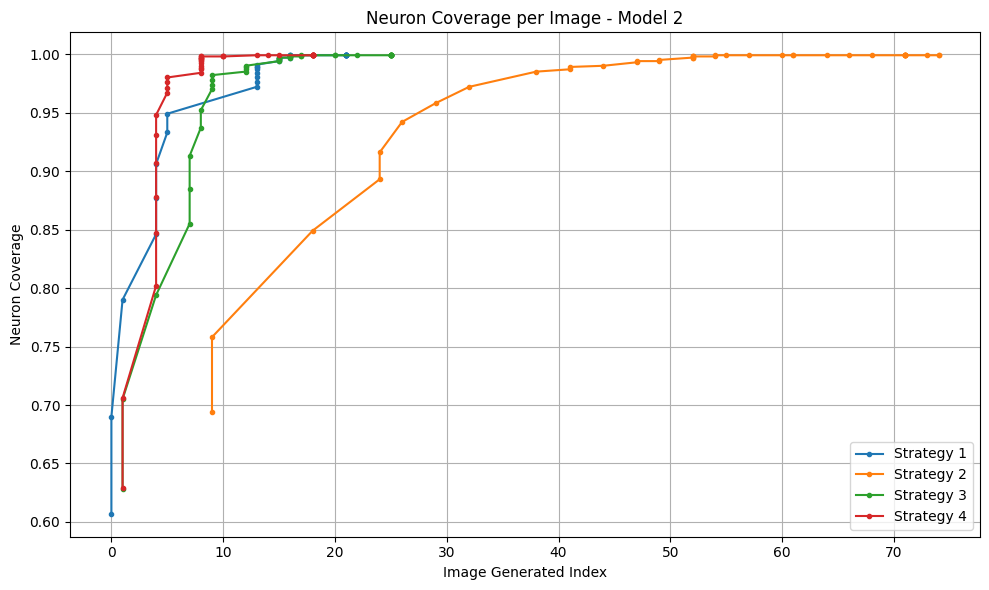

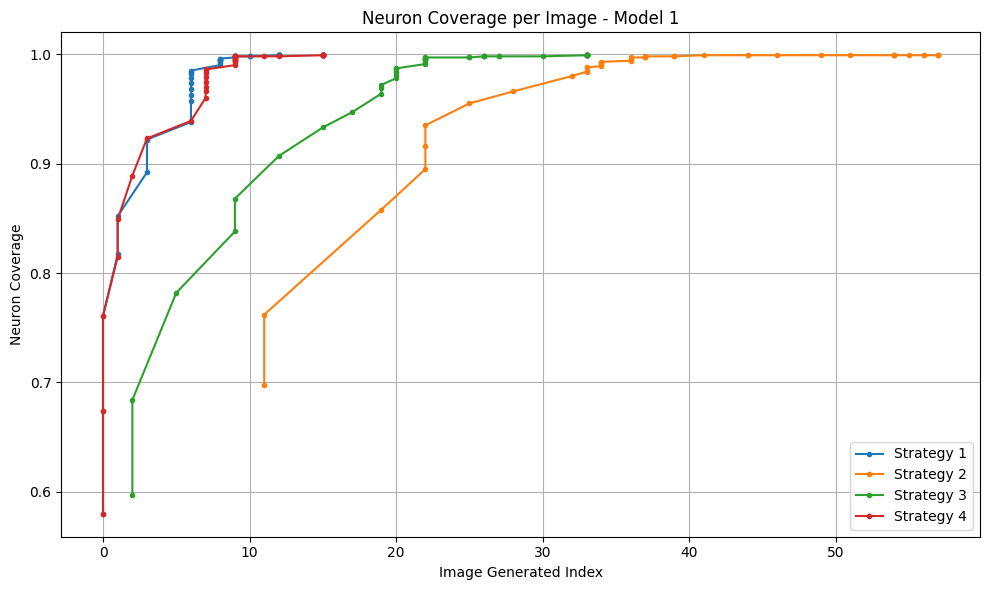

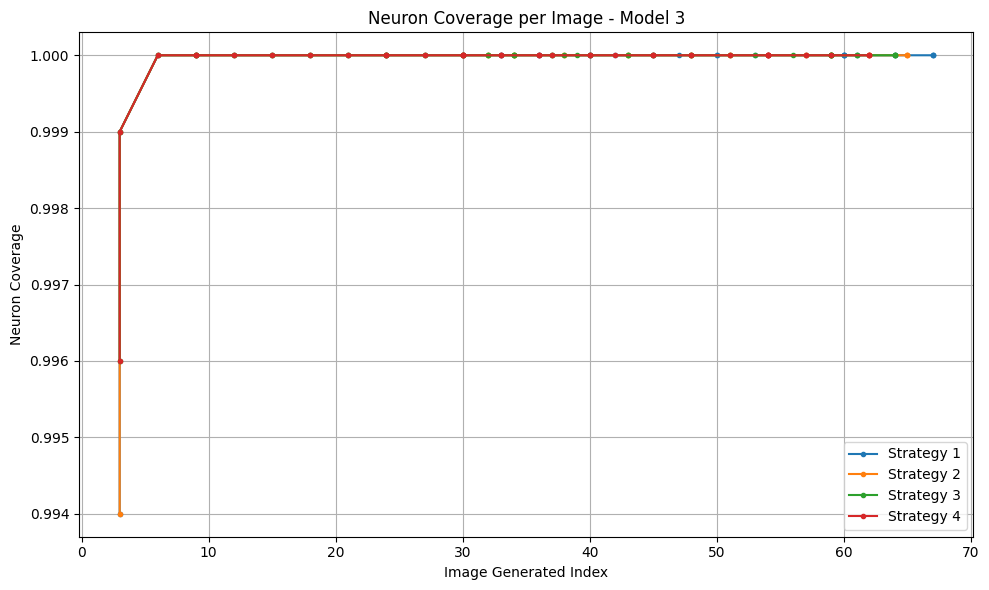

In [ ]:
import os
import re
import matplotlib.pyplot as plt

folder_path = "TFG/DLFuzz/Resultats_imagenet"

# Diccionari: model -> {estratègia -> (x_vals, y_vals)}
models_data = {}

for filename in os.listdir(folder_path):
    if filename.endswith(".txt") and "DLFuzz_imagenet_10" in filename:
        filepath = os.path.join(folder_path, filename)

        match = re.search(r'DLFuzz_imagenet_10_(\d+)(\d+)\.txt', filename)
        if match:
            model = match.group(1)
            strategy = int(match.group(2))+1

            with open(filepath, "r") as f:
                lines = f.readlines()

            image_index = 0
            x_vals = []
            y_vals = []

            for line in lines:
                if line.startswith("generated image:"):
                    image_index += 1
                elif "covered neurons percentage" in line:
                    match_cov = re.search(r'([0-9.]+)\s*$', line)
                    if match_cov:
                        coverage = float(match_cov.group(1))
                        x_vals.append(image_index)
                        y_vals.append(coverage)

            if model not in models_data:
                models_data[model] = {}
            models_data[model][strategy] = (x_vals, y_vals)

for model, strategies in models_data.items():
    plt.figure(figsize=(10, 6))
    # for strategy, (x, y) in strategies.items():
    #     label = f"Strategy {strategy}"
    #     plt.plot(x, y, label=label)#, marker='o')
    for strategy in sorted(strategies.keys()):
        x, y = strategies[strategy]
        label = f"Strategy {strategy}"
        plt.plot(x, y, label=label, marker='o', markersize=3)

    plt.title(f"Neuron Coverage per Image - Model {model}")
    plt.xlabel("Image Generated Index")
    plt.ylabel("Neuron Coverage")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## DeepXplore vs. DLFuzz

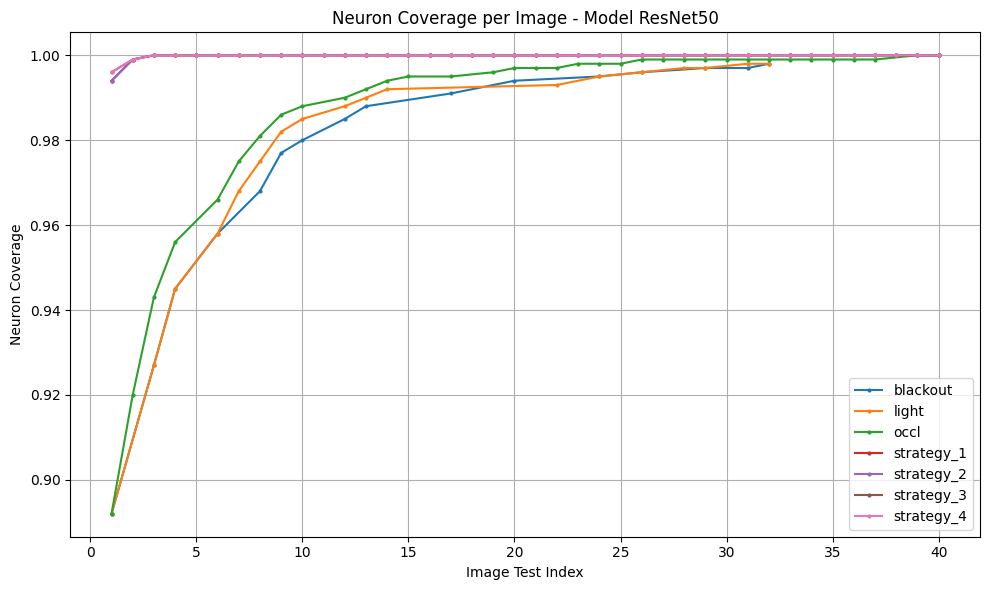

In [ ]:
import os
import re
import matplotlib.pyplot as plt

dlfuzz_dir = 'TFG/DLFuzz/Resultats_imagenet'
deep_dir = 'TFG/DeepXplore/imagenet_DLFuzz_images_strategies'

models_data = {}

def process_dlfuzz_file(filename, filepath):
    match = re.search(r'DLFuzz_imagenet_(\d+)(\d+)_(\d+)(\d+)\.txt', filename)
    if not match:
        return
    model = 3
    strategy = f"strategy_{int(match.group(4)) + 1}"

    with open(filepath, 'r') as f:
        lines = f.readlines()

    x, y = [], []
    image_count = 0
    for line in lines:
        if line.startswith("Image path:"):
            image_count += 1
        elif "covered neurons percentage" in line:
            coverage = float(re.search(r'([0-9.]+)$', line.strip()).group(1))
            x.append(image_count)
            y.append(coverage)
    # print(model)
    models_data.setdefault(model, {})[strategy] = (x, y)

def process_deep_file(filename, filepath):
    match = re.search(r'output_ImageNet_strategy_(\w+)(\d+)\.txt', filename)
    if not match:
        print('no match')
        return
    strategy = match.group(1)
    model = 3

    with open(filepath, 'r') as f:
        lines = f.readlines()

    x, y = [], []
    image_count = 0
    for line in lines:
        if line.startswith("Image path:"):
            image_count += 1
        elif line.startswith("averaged covered neurons"):
            coverage = float(re.search(r'([0-9.]+)', line).group(1))
            x.append(image_count)
            y.append(coverage)
    # print(model)
    models_data.setdefault(model, {})[strategy] = (x, y)

for filename in os.listdir(dlfuzz_dir):
    if filename.endswith(".txt"):
        process_dlfuzz_file(filename, os.path.join(dlfuzz_dir, filename))

for filename in os.listdir(deep_dir):
    if filename.endswith(".txt"):
        process_deep_file(filename, os.path.join(deep_dir, filename))

for model in sorted(models_data.keys()):
    plt.figure(figsize=(10, 6))
    for strategy in sorted(models_data[model].keys()):
        x, y = models_data[model][strategy]
        plt.plot(x, y, label=strategy, marker='o', markersize=2)

    if model == 1:
        plt.title(f"Neuron Coverage per Image - Model VGG16")
    elif model == 2:
        plt.title(f"Neuron Coverage per Image - Model VGG19")
    elif model == 3:
        plt.title(f"Neuron Coverage per Image - Model ResNet50")
    plt.xlabel("Image Test Index")
    plt.ylabel("Neuron Coverage")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Senyals

## Només estratègies DLFuzz

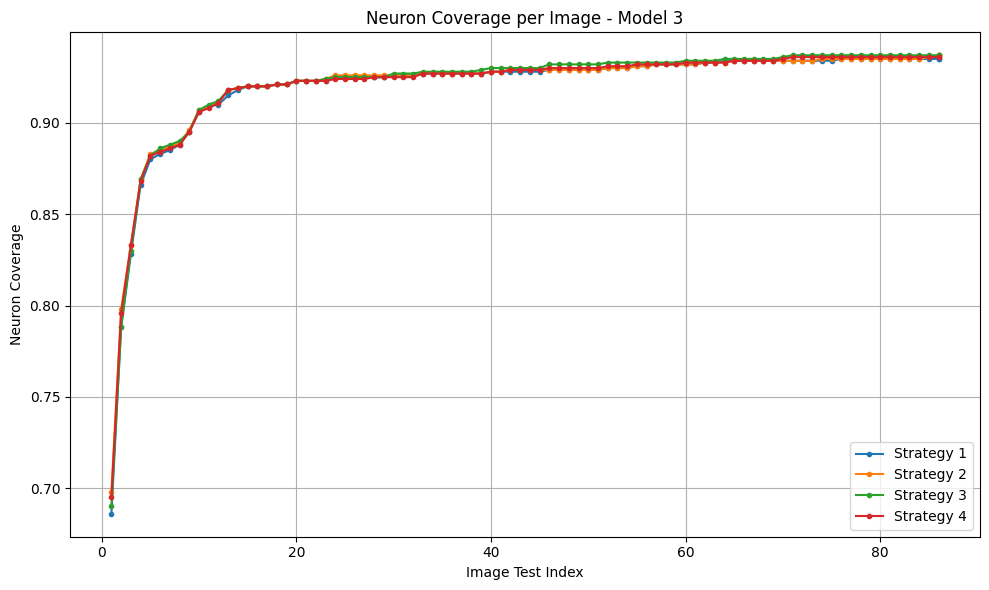

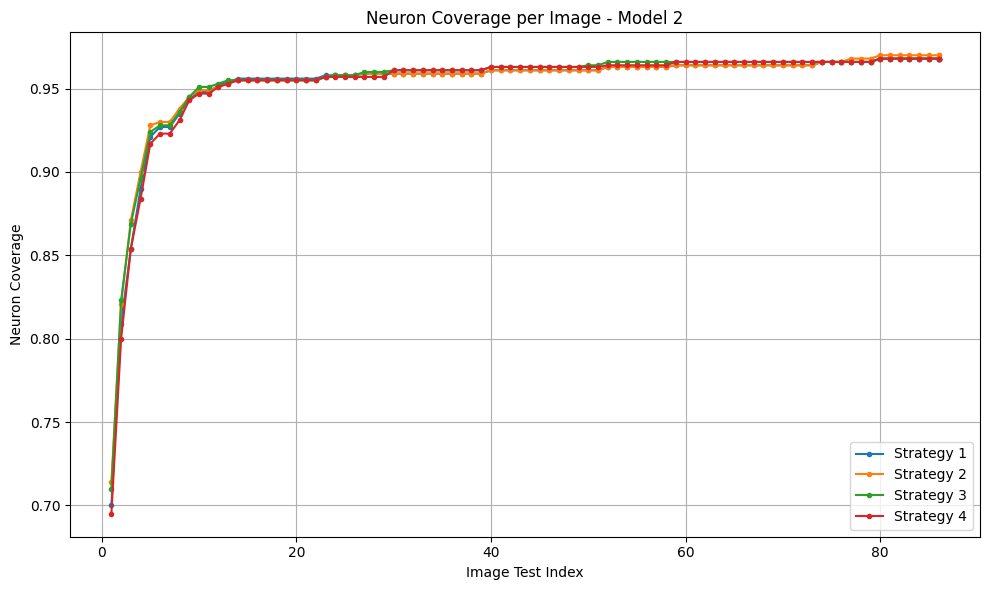

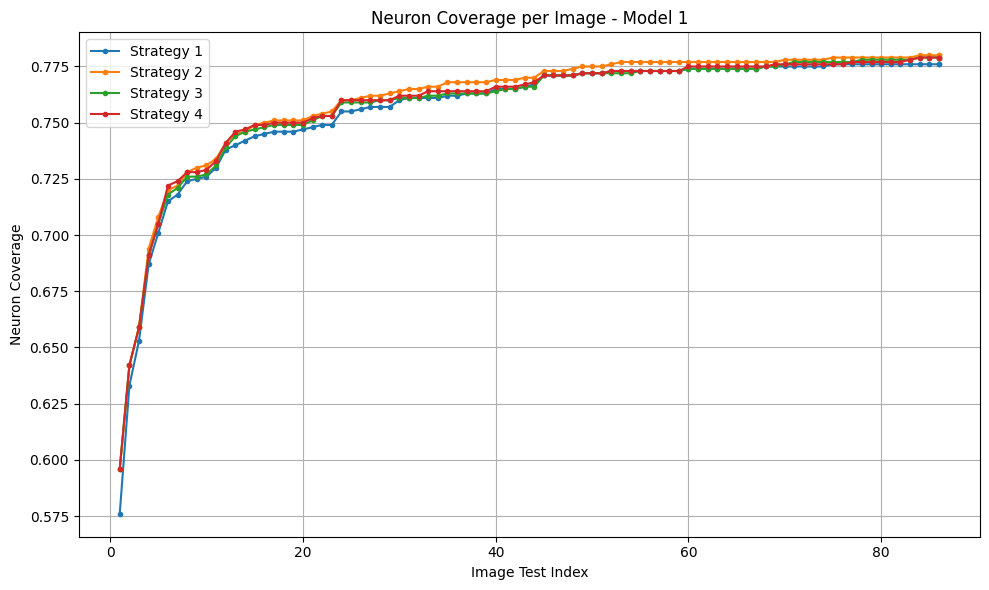

In [ ]:
import os
import re
import matplotlib.pyplot as plt

folder_path = "TFG/DLFuzz/RResultats_DLFuzz_GTSRB"

# Diccionari: model -> {estratègia -> (x_vals, y_vals)}
models_data = {}

for filename in os.listdir(folder_path):
    if filename.endswith(".txt") and "output_2DLFuzz" in filename:
        filepath = os.path.join(folder_path, filename)

        match = re.search(r'output_2DLFuzz_2senyals(\d+)(\d+)\.txt', filename)
        if match:
            model = match.group(1)
            strategy = int(match.group(2))+1

            with open(filepath, "r") as f:
                lines = f.readlines()

            image_index = 0
            x_vals = []
            y_vals = []

            for line in lines:
                if line.startswith("Image path:"):
                    image_index += 1
                elif "covered neurons percentage" in line:
                    match_cov = re.search(r'([0-9.]+)\s*$', line)
                    if match_cov:
                        coverage = float(match_cov.group(1))
                        x_vals.append(image_index)
                        y_vals.append(coverage)

            if model not in models_data:
                models_data[model] = {}
            models_data[model][strategy] = (x_vals, y_vals)

for model, strategies in models_data.items():
    plt.figure(figsize=(10, 6))
    # for strategy, (x, y) in strategies.items():
    #     label = f"Strategy {strategy}"
    #     plt.plot(x, y, label=label)#, marker='o')
    for strategy in sorted(strategies.keys()):
        x, y = strategies[strategy]
        label = f"Strategy {strategy}"
        plt.plot(x, y, label=label, marker='o', markersize=3)

    plt.title(f"Neuron Coverage per Image - Model {model}")
    plt.xlabel("Image Test Index")
    plt.ylabel("Neuron Coverage")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


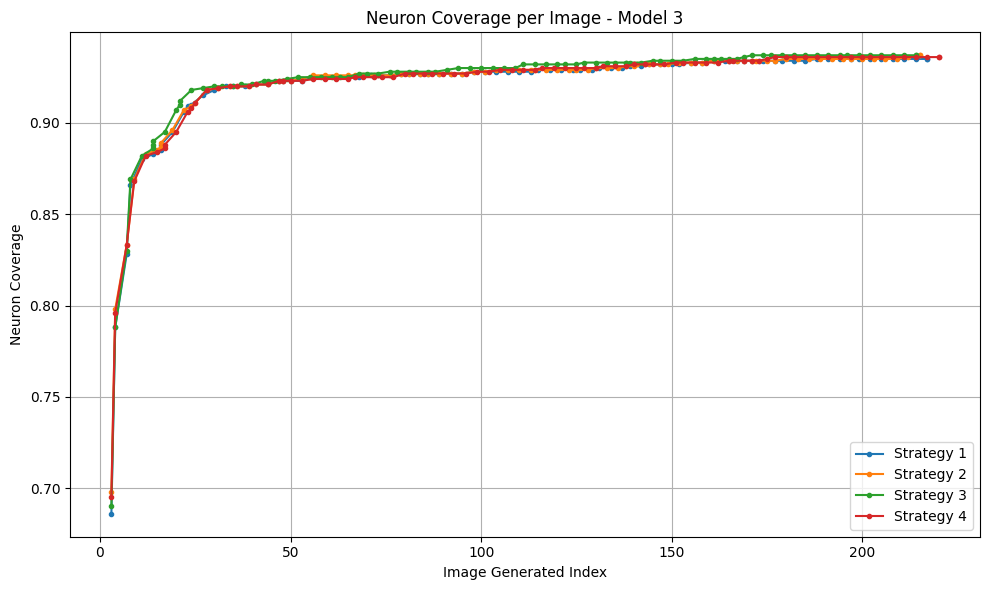

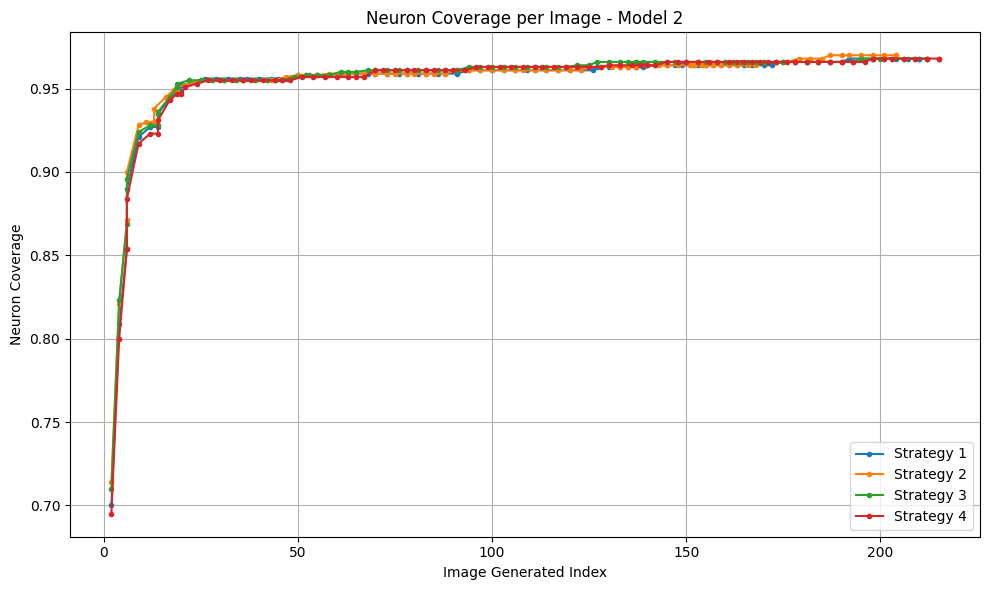

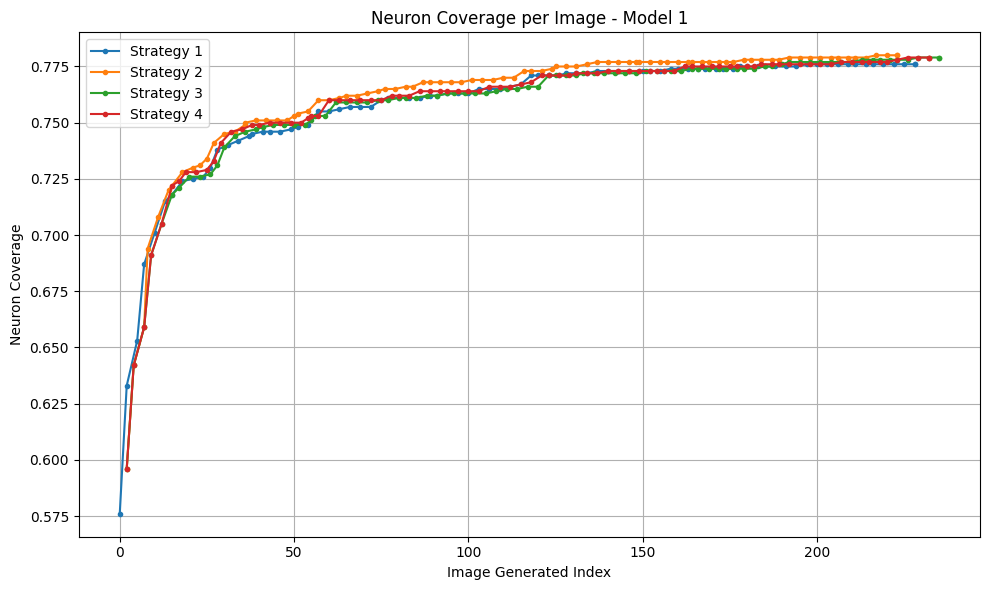

In [ ]:
import os
import re
import matplotlib.pyplot as plt

folder_path = "TFG/DLFuzz/Resultats_DLFuzz_GTSRB/"

# Diccionari: model -> {estratègia -> (x_vals, y_vals)}
models_data = {}

for filename in os.listdir(folder_path):
    if filename.endswith(".txt") and "output_2DLFuzz" in filename:
        filepath = os.path.join(folder_path, filename)

        match = re.search(r'output_2DLFuzz_2senyals(\d+)(\d+)\.txt', filename)
        if match:
            model = match.group(1)
            strategy = int(match.group(2))+1

            with open(filepath, "r") as f:
                lines = f.readlines()

            image_index = 0
            x_vals = []
            y_vals = []

            for line in lines:
                if line.startswith("generated image:"):
                    image_index += 1
                elif "covered neurons percentage" in line:
                    match_cov = re.search(r'([0-9.]+)\s*$', line)
                    if match_cov:
                        coverage = float(match_cov.group(1))
                        x_vals.append(image_index)
                        y_vals.append(coverage)

            if model not in models_data:
                models_data[model] = {}
            models_data[model][strategy] = (x_vals, y_vals)

for model, strategies in models_data.items():
    plt.figure(figsize=(10, 6))
    # for strategy, (x, y) in strategies.items():
    #     label = f"Strategy {strategy}"
    #     plt.plot(x, y, label=label)#, marker='o')
    for strategy in sorted(strategies.keys()):
        x, y = strategies[strategy]
        label = f"Strategy {strategy}"
        plt.plot(x, y, label=label, marker='o', markersize=3)

    plt.title(f"Neuron Coverage per Image - Model {model}")
    plt.xlabel("Image Generated Index")
    plt.ylabel("Neuron Coverage")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()




---



## DLFuzz vs. DeepXplore

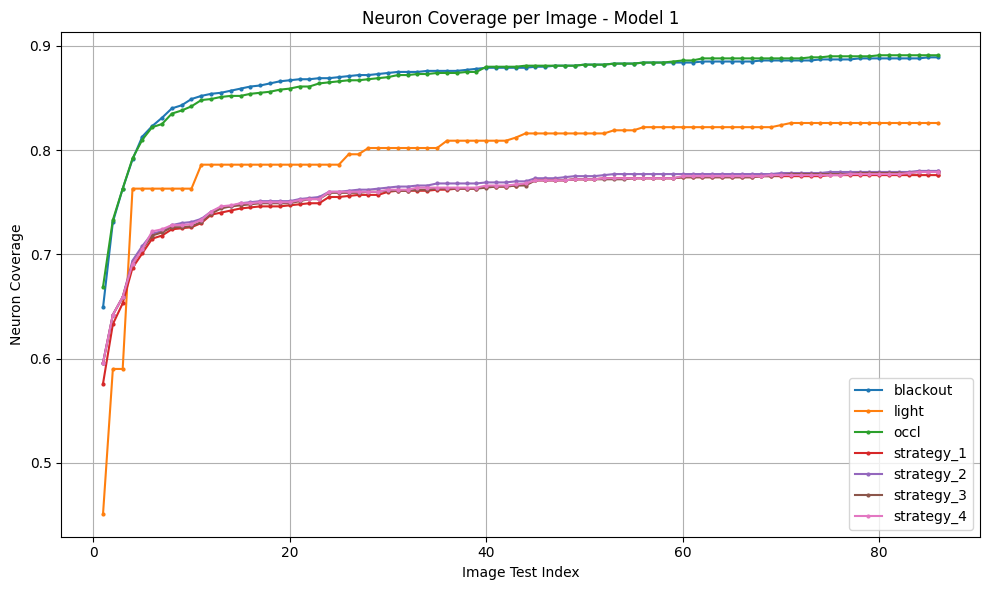

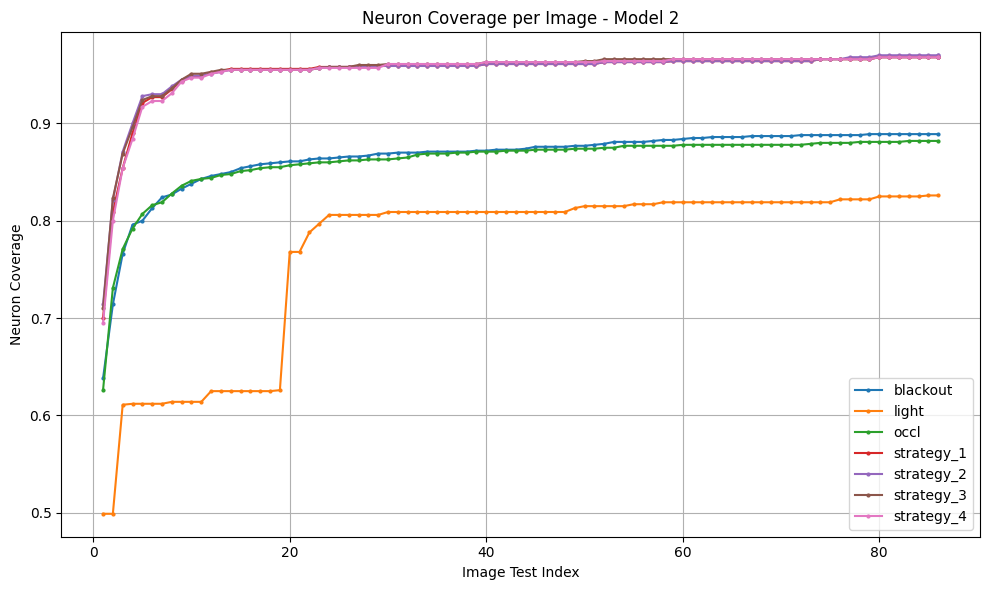

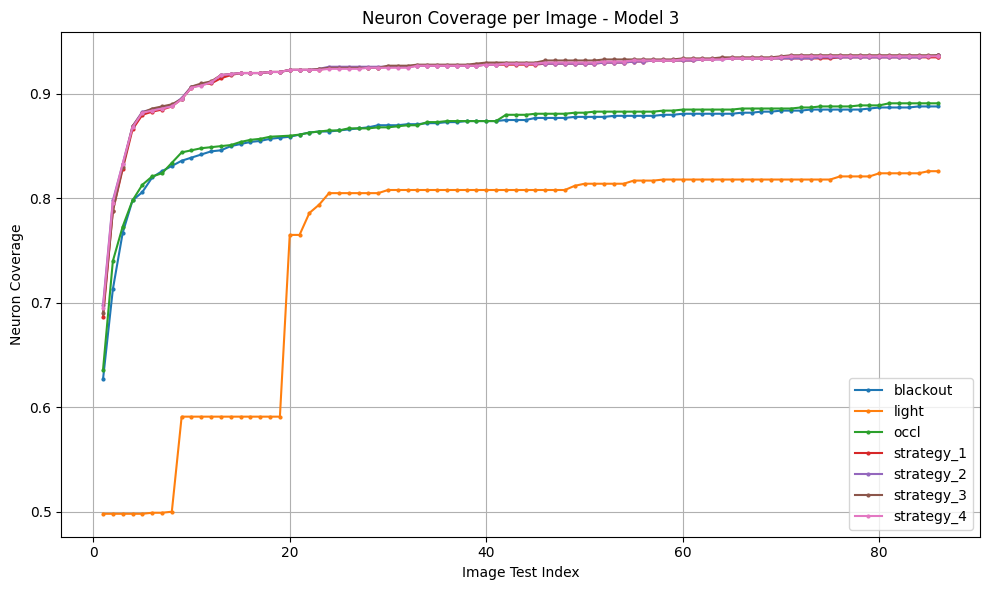

In [ ]:
import os
import re
import matplotlib.pyplot as plt

dlfuzz_dir = 'TFG/DLFuzz/Resultats_DLFuzz_GTSRB'
deep_dir = 'TFG/DeepXplore/GTSRB/Models_123/Resultats per comparació estrategies'

models_data = {}

def process_dlfuzz_file(filename, filepath):
    match = re.search(r'output_2DLFuzz_2senyals(\d+)(\d+)\.txt', filename)
    if not match:
        return
    model = int(match.group(1))
    strategy = f"strategy_{int(match.group(2)) + 1}"

    with open(filepath, 'r') as f:
        lines = f.readlines()

    x, y = [], []
    image_count = 0
    for line in lines:
        if line.startswith("Image path:"):
            image_count += 1
        elif "covered neurons percentage" in line:
            coverage = float(re.search(r'([0-9.]+)$', line.strip()).group(1))
            x.append(image_count)
            y.append(coverage)
    # print(model)
    models_data.setdefault(model, {})[strategy] = (x, y)

def process_deep_file(filename, filepath):
    match = re.search(r'output_trafficsigns_dlfuzzimgs_(\w+)(\d+)\.txt', filename)
    if not match:
        return
    strategy = match.group(1)
    model = int(match.group(2)) +1

    with open(filepath, 'r') as f:
        lines = f.readlines()

    x, y = [], []
    image_count = 0
    for line in lines:
        if line.startswith("Image path:"):
            image_count += 1
        elif line.startswith("averaged covered neurons"):
            coverage = float(re.search(r'([0-9.]+)', line).group(1))
            x.append(image_count)
            y.append(coverage)
    # print(model)
    models_data.setdefault(model, {})[strategy] = (x, y)

for filename in os.listdir(dlfuzz_dir):
    if filename.endswith(".txt"):
        process_dlfuzz_file(filename, os.path.join(dlfuzz_dir, filename))

for filename in os.listdir(deep_dir):
    if filename.endswith(".txt"):
        process_deep_file(filename, os.path.join(deep_dir, filename))

for model in sorted(models_data.keys()):
    plt.figure(figsize=(10, 6))
    for strategy in sorted(models_data[model].keys()):
        x, y = models_data[model][strategy]
        plt.plot(x, y, label=strategy, marker='o', markersize=2)

    plt.title(f"Neuron Coverage per Image - Model {model}")
    plt.xlabel("Image Test Index")
    plt.ylabel("Neuron Coverage")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()




---



---



---





---



---



---



## Comprovació Resultats:

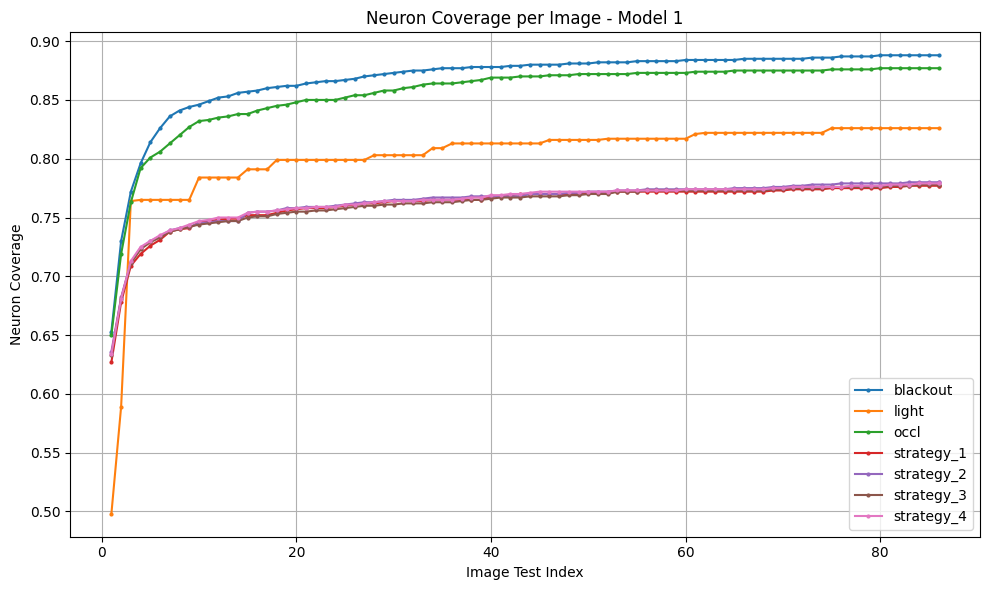

In [ ]:
import os
import re
import matplotlib.pyplot as plt

dlfuzz_dir = 'TFG/DLFuzz/Resultats_diferents_versions_dels_models'
deep_dir = 'TFG/DeepXplore/GTSRB/Models_123/Resultats per comparació estrategies'

models_data = {}

def process_dlfuzz_file(filename, filepath):
    match = re.search(r'output_2DLFuzz_2senyals(\d+)(\d+)\.txt', filename)
    if not match:
        return
    model = int(match.group(1)) +1
    strategy = f"strategy_{int(match.group(2))}"

    with open(filepath, 'r') as f:
        lines = f.readlines()

    x, y = [], []
    image_count = 0
    for line in lines:
        if line.startswith("Image path:"):
            image_count += 1
        elif "covered neurons percentage" in line:
            coverage = float(re.search(r'([0-9.]+)$', line.strip()).group(1))
            x.append(image_count)
            y.append(coverage)
    # print(model)
    models_data.setdefault(model, {})[strategy] = (x, y)

def process_deep_file(filename, filepath):
    match = re.search(r'output_trafficsigns_dlfuzzimgs_(\w+)(\d+)(\d+)\.txt', filename)
    if not match:
        return
    strategy = match.group(1)
    model = int(match.group(2)) +1

    with open(filepath, 'r') as f:
        lines = f.readlines()

    x, y = [], []
    image_count = 0
    for line in lines:
        if line.startswith("Image path:"):
            image_count += 1
        elif line.startswith("averaged covered neurons"):
            coverage = float(re.search(r'([0-9.]+)', line).group(1))
            x.append(image_count)
            y.append(coverage)
    # print(model)
    models_data.setdefault(model, {})[strategy] = (x, y)

for filename in os.listdir(dlfuzz_dir):
    if filename.endswith(".txt"):
        process_dlfuzz_file(filename, os.path.join(dlfuzz_dir, filename))

for filename in os.listdir(deep_dir):
    if filename.endswith(".txt"):
        process_deep_file(filename, os.path.join(deep_dir, filename))

for model in sorted(models_data.keys()):
    plt.figure(figsize=(10, 6))
    for strategy in sorted(models_data[model].keys()):
        x, y = models_data[model][strategy]
        plt.plot(x, y, label=strategy, marker='o', markersize=2)

    plt.title(f"Neuron Coverage per Image - Model {model}")
    plt.xlabel("Image Test Index")
    plt.ylabel("Neuron Coverage")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()





---



---



---



---



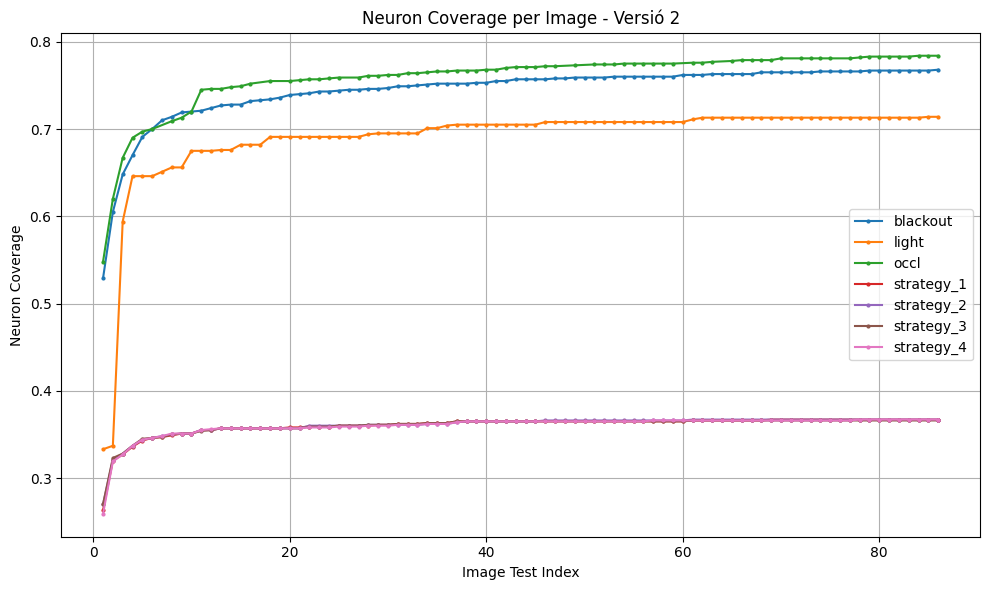

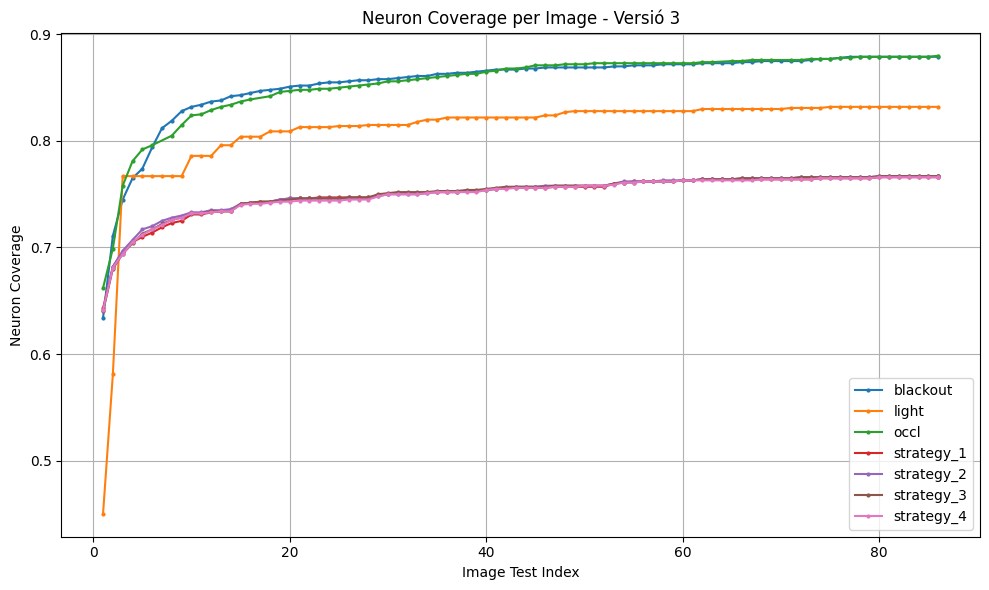

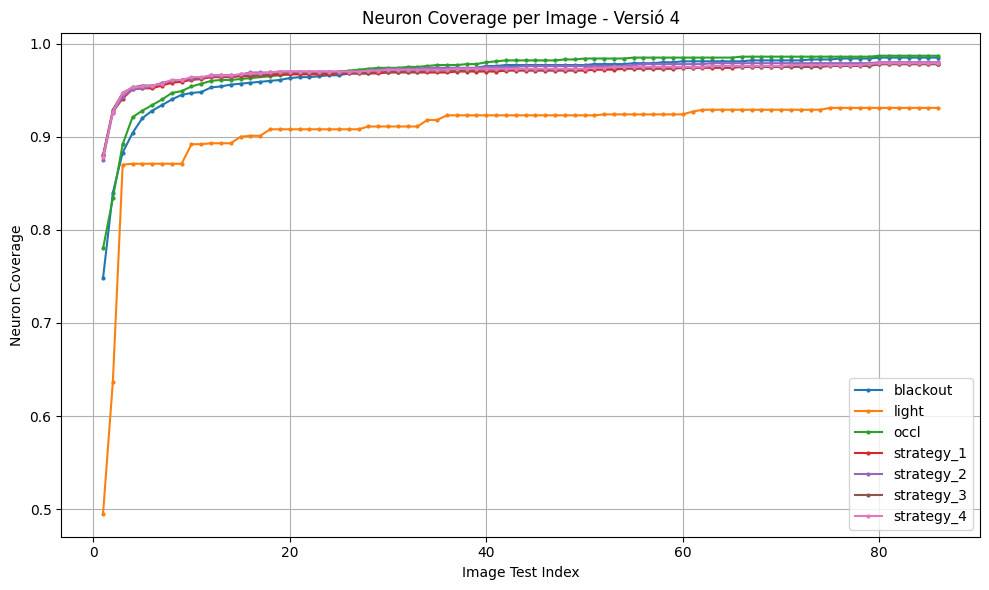

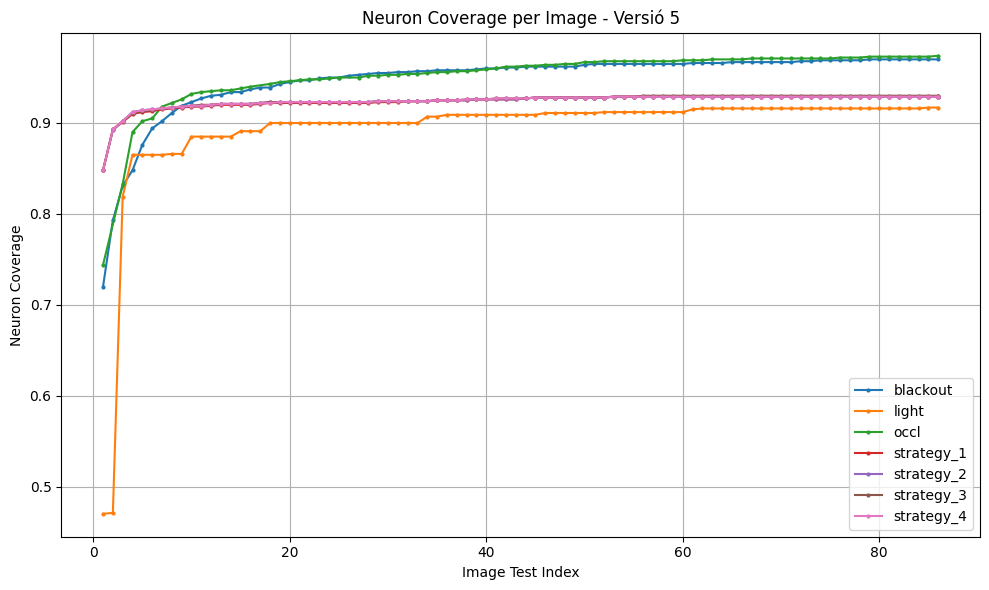

In [ ]:
import os
import re
import matplotlib.pyplot as plt

dlfuzz_dir = 'TFG/DLFuzz/Resultats_diferents_versions_dels_models'
deep_dir = 'TFG/DeepXplore/GTSRB/Models_123/Resultats per comparació estrategies'

models_data = {}

def process_dlfuzz_file(filename, filepath):
    match = re.search(r'output_2DLFuzz_2senyals0(\d+)_v(\d+)\.txt', filename)
    if not match:
        return
    model = int(match.group(2))
    strategy = f"strategy_{int(match.group(1))}"

    with open(filepath, 'r') as f:
        lines = f.readlines()

    x, y = [], []
    image_count = 0
    for line in lines:
        if line.startswith("Image path:"):
            image_count += 1
        elif "covered neurons percentage" in line:
            coverage = float(re.search(r'([0-9.]+)$', line.strip()).group(1))
            x.append(image_count)
            y.append(coverage)
    # print(model)
    models_data.setdefault(model, {})[strategy] = (x, y)

def process_deep_file(filename, filepath):
    match = re.search(r'output_trafficsigns_dlfuzzimgs_(\w+)0_v(\d+)\.txt', filename)
    if not match:
        return
    strategy = match.group(1)
    model = int(match.group(2))

    with open(filepath, 'r') as f:
        lines = f.readlines()

    x, y = [], []
    image_count = 0
    for line in lines:
        if line.startswith("Image path:"):
            image_count += 1
        elif line.startswith("averaged covered neurons"):
            coverage = float(re.search(r'([0-9.]+)', line).group(1))
            x.append(image_count)
            y.append(coverage)
    # print(model)
    models_data.setdefault(model, {})[strategy] = (x, y)

for filename in os.listdir(dlfuzz_dir):
    if filename.endswith(".txt"):
        process_dlfuzz_file(filename, os.path.join(dlfuzz_dir, filename))

for filename in os.listdir(deep_dir):
    if filename.endswith(".txt"):
        process_deep_file(filename, os.path.join(deep_dir, filename))

for model in sorted(models_data.keys()):
    plt.figure(figsize=(10, 6))
    for strategy in sorted(models_data[model].keys()):
        x, y = models_data[model][strategy]
        plt.plot(x, y, label=strategy, marker='o', markersize=2)

    plt.title(f"Neuron Coverage per Image - Versió {model}")
    plt.xlabel("Image Test Index")
    plt.ylabel("Neuron Coverage")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



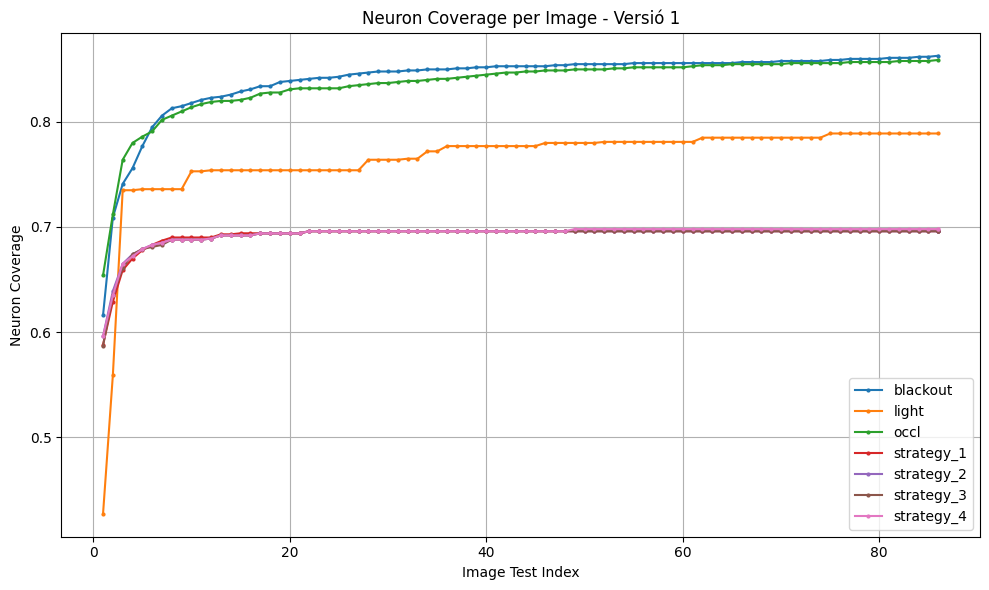

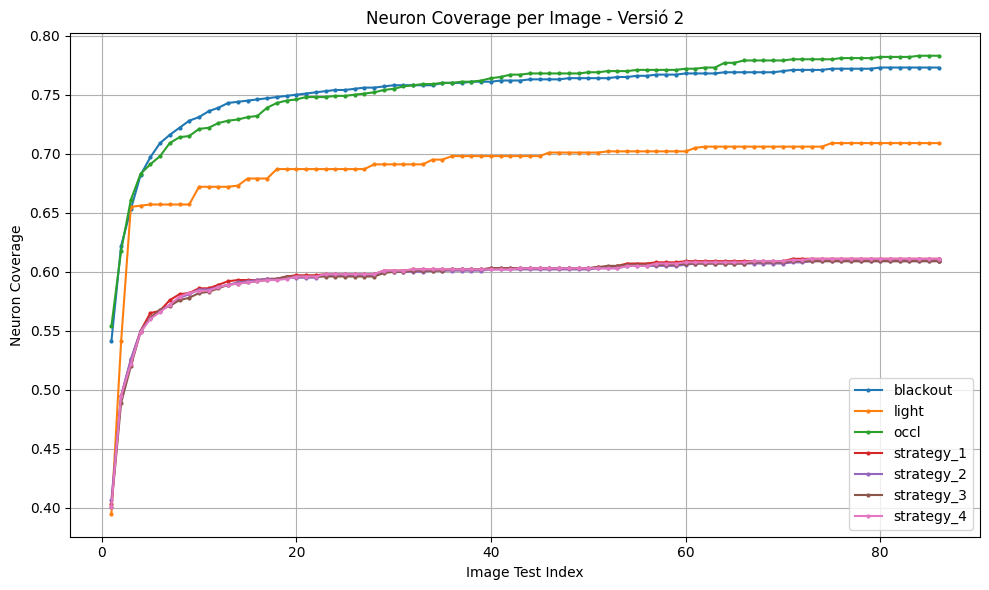

In [ ]:
import os
import re
import matplotlib.pyplot as plt

dlfuzz_dir = 'TFG/DLFuzz/Resultats_diferents_versions_dels_models'
deep_dir = 'TFG/DeepXplore/GTSRB/Models_123/Resultats per comparació estrategies'

models_data = {}

def process_dlfuzz_file(filename, filepath):
    match = re.search(r'output_2DLFuzz_2senyals(\d+)(\d+)_v2\.txt', filename)
    if not match:
        print("No Match")
        return
    model = int(match.group(1))
    strategy = f"strategy_{int(match.group(2))}"

    with open(filepath, 'r') as f:
        lines = f.readlines()

    x, y = [], []
    image_count = 0
    for line in lines:
        if line.startswith("Image path:"):
            image_count += 1
        elif "covered neurons percentage" in line:
            coverage = float(re.search(r'([0-9.]+)$', line.strip()).group(1))
            x.append(image_count)
            y.append(coverage)
    # print(model)
    models_data.setdefault(model, {})[strategy] = (x, y)

def process_deep_file(filename, filepath):
    match = re.search(r'output_trafficsigns_dlfuzzimgs_(\w+)(\d+)_v2\.txt', filename)
    if not match:
        print("No Match")
        return
    strategy = match.group(1)
    model = int(match.group(2))

    with open(filepath, 'r') as f:
        lines = f.readlines()

    x, y = [], []
    image_count = 0
    for line in lines:
        if line.startswith("Image path:"):
            image_count += 1
        elif line.startswith("averaged covered neurons"):
            coverage = float(re.search(r'([0-9.]+)', line).group(1))
            x.append(image_count)
            y.append(coverage)
    # print(model)
    models_data.setdefault(model, {})[strategy] = (x, y)

for filename in os.listdir(dlfuzz_dir):
    if filename.endswith(".txt"):
        process_dlfuzz_file(filename, os.path.join(dlfuzz_dir, filename))

for filename in os.listdir(deep_dir):
    if filename.endswith(".txt"):
        process_deep_file(filename, os.path.join(deep_dir, filename))

for model in sorted(models_data.keys()):
    plt.figure(figsize=(10, 6))
    for strategy in sorted(models_data[model].keys()):
        x, y = models_data[model][strategy]
        plt.plot(x, y, label=strategy, marker='o', markersize=2)

    plt.title(f"Neuron Coverage per Image - Versió {model}")
    plt.xlabel("Image Test Index")
    plt.ylabel("Neuron Coverage")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

